# Detector

In this notebook the part of the Streetsign-model, detects and predicts the bounding Boxes of the Streetsigns in the Images, is trained

## Training
a pretrained YOLOv8s model is trained on parts of the Mapillary traffic sign dataset

In [12]:
from ultralytics import YOLO
import torch


def main():
    import os
    print(os.getcwd())
    # OPTIONAL: print device info
    print("CUDA available:", torch.cuda.is_available())

    # Load COCO-pretrained YOLOv8-small
    # You may want yolov8n.pt for faster CPU training
    model = YOLO("../yolov8s.pt")

    # Train on your dataset using CPU
    results = model.train(
        data="street_signs/mapillary.yaml",          # path to dataset YAML
        epochs=25,                      # reduce for CPU
        imgsz=640,                      # smaller size = faster on CPU
        batch=4,                        # MUST be small on CPU
        device="cpu",                   # force CPU
        workers=2,                      # reduce workers
        name="yolov8s_mapillary_subset_cpu"
    )


if __name__ == "__main__":
    main()



E:\DataMiningProj
CUDA available: False
Ultralytics 8.3.248  Python-3.12.11 torch-2.5.1 CPU (13th Gen Intel Core i5-13600KF)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=street_signs/mapillary.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=25, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=../yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=yolov8s_mapillary_subset_cpu10, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, o

## Inference and Visualization

In [1]:
from ultralytics import YOLO

# Path to your trained model
MODEL_PATH = "runs/detect/yolov8s_mapillary_subset_cpu10/weights/best.pt"

# Load model
yolo_model = YOLO(MODEL_PATH)

print("Model loaded successfully")

Model loaded successfully



0: 480x640 3 streetsigns, 111.0ms
Speed: 5.0ms preprocess, 111.0ms inference, 1.8ms postprocess per image at shape (1, 3, 480, 640)


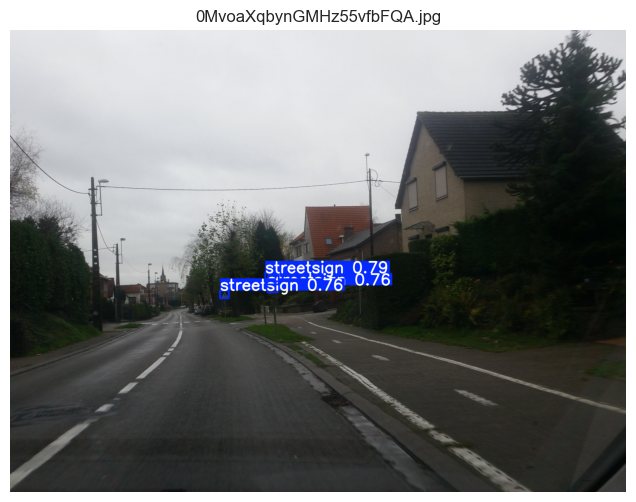

In [13]:
import matplotlib.pyplot as plt
from PIL import Image
import glob

IMAGE_DIR = r"E:\DataMiningProj\Git_project\street_signs\dataset\images\val\0MvoaXqbynGMHz55vfbFQA.jpg"

image_paths = sorted(
    glob.glob(f"{IMAGE_DIR}/*.jpg") +
    glob.glob(f"{IMAGE_DIR}/*.png")
)[:25]

image_paths = sorted(
    glob.glob(f"{IMAGE_DIR}")
)[:25]

for img_path in image_paths:
    results = yolo_model(image_paths, conf=0.3)

    annotated = results[0].plot()
    annotated = annotated[:, :, ::-1]  # BGR → RGB

    plt.figure(figsize=(10, 6))
    plt.imshow(annotated)
    plt.title(img_path.split("\\")[-1])
    plt.axis("off")

    plt.show(block=True)
    plt.close()



## Evaluation

In [3]:
import os
import glob
import numpy as np
from PIL import Image
from collections import defaultdict

# -----------------------------
# CONFIG
# -----------------------------
IMAGE_DIR = r"E:\DataMiningProj\Git_project\street_signs\dataset\images\val"
LABEL_DIR = r"E:\DataMiningProj\Git_project\street_signs\dataset\labels\val"

CONF_THRESH = 0.3
IOU_THRESH = 0.5

# -----------------------------
# UTILS
# -----------------------------
def yolo_to_xyxy(box, img_w, img_h):
    """
    YOLO format (x_center, y_center, w, h) -> pixel xyxy
    """
    x, y, w, h = box
    x1 = (x - w / 2) * img_w
    y1 = (y - h / 2) * img_h
    x2 = (x + w / 2) * img_w
    y2 = (y + h / 2) * img_h
    return np.array([x1, y1, x2, y2])


def compute_iou(box1, box2):
    """
    box format: [x1, y1, x2, y2]
    """
    xA = max(box1[0], box2[0])
    yA = max(box1[1], box2[1])
    xB = min(box1[2], box2[2])
    yB = min(box1[3], box2[3])

    inter_w = max(0, xB - xA)
    inter_h = max(0, yB - yA)
    inter_area = inter_w * inter_h

    box1_area = (box1[2] - box1[0]) * (box1[3] - box1[1])
    box2_area = (box2[2] - box2[0]) * (box2[3] - box2[1])

    union = box1_area + box2_area - inter_area
    return inter_area / union if union > 0 else 0


def load_gt_labels(label_path, img_w, img_h):
    """
    Load YOLO GT labels and convert to xyxy
    """
    boxes = []
    if not os.path.exists(label_path):
        return boxes

    with open(label_path, "r") as f:
        for line in f:
            parts = line.strip().split()
            cls = int(parts[0])
            box = list(map(float, parts[1:5]))
            boxes.append(yolo_to_xyxy(box, img_w, img_h))
    return boxes


# -----------------------------
# EVALUATION
# -----------------------------
image_paths = sorted(
    glob.glob(os.path.join(IMAGE_DIR, "*.jpg")) +
    glob.glob(os.path.join(IMAGE_DIR, "*.png"))
)

TP = 0
FP = 0
FN = 0

for img_path in image_paths:
    img = Image.open(img_path)
    img_w, img_h = img.size

    # Load GT
    label_path = os.path.join(
        LABEL_DIR,
        os.path.splitext(os.path.basename(img_path))[0] + ".txt"
    )
    gt_boxes = load_gt_labels(label_path, img_w, img_h)
    matched_gt = [False] * len(gt_boxes)

    # Run inference
    results = yolo_model(img_path, conf=CONF_THRESH)[0]

    if results.boxes is None:
        # No predictions
        FN += len(gt_boxes)
        continue

    preds = results.boxes.xyxy.cpu().numpy()

    # Match predictions to GT
    for pred in preds:
        ious = [compute_iou(pred, gt) for gt in gt_boxes]
        if len(ious) == 0 or max(ious) < IOU_THRESH:
            FP += 1
        else:
            best_idx = int(np.argmax(ious))
            if not matched_gt[best_idx]:
                TP += 1
                matched_gt[best_idx] = True
            else:
                FP += 1

    FN += matched_gt.count(False)

# -----------------------------
# METRICS
# -----------------------------
precision = TP / (TP + FP) if (TP + FP) > 0 else 0
recall = TP / (TP + FN) if (TP + FN) > 0 else 0
f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
accuracy = TP / (TP + FP + FN) if (TP + FP + FN) > 0 else 0

# -----------------------------
# RESULTS
# -----------------------------
print("\n===== EVALUATION RESULTS =====")
print(f"Images evaluated : {len(image_paths)}")
print(f"True Positives   : {TP}")
print(f"False Positives  : {FP}")
print(f"False Negatives  : {FN}\n")

print(f"Precision        : {precision:.4f}")
print(f"Recall           : {recall:.4f}")
print(f"F1 Score         : {f1:.4f}")
print(f"Accuracy         : {accuracy:.4f}")



image 1/1 E:\DataMiningProj\Git_project\street_signs\dataset\images\val\--USokD3k9HzZbwzNZntiQ.jpg: 480x640 1 streetsign, 69.4ms
Speed: 1.8ms preprocess, 69.4ms inference, 0.4ms postprocess per image at shape (1, 3, 480, 640)

image 1/1 E:\DataMiningProj\Git_project\street_signs\dataset\images\val\--zM9JXM7e2uVsRfC-c_Tg.jpg: 480x640 1 streetsign, 65.9ms
Speed: 1.3ms preprocess, 65.9ms inference, 0.6ms postprocess per image at shape (1, 3, 480, 640)

image 1/1 E:\DataMiningProj\Git_project\street_signs\dataset\images\val\-0iIhj9Oc7tOo-ydUgveRA.jpg: 480x640 1 streetsign, 57.5ms
Speed: 1.2ms preprocess, 57.5ms inference, 0.4ms postprocess per image at shape (1, 3, 480, 640)

image 1/1 E:\DataMiningProj\Git_project\street_signs\dataset\images\val\-1CI3lnupBv6C18BvKbhDg.jpg: 480x640 5 streetsigns, 63.8ms
Speed: 1.5ms preprocess, 63.8ms inference, 0.3ms postprocess per image at shape (1, 3, 480, 640)

image 1/1 E:\DataMiningProj\Git_project\street_signs\dataset\images\val\-1exc-EDWIlSZ0JN_O

In [8]:
from ultralytics import YOLO

model = YOLO("runs/detect/yolov8s_mapillary_subset_cpu10/weights/best.pt")

metrics = model.val(
    data="mapillary.yaml",
    conf=0.3,     # confidence threshold
    iou=0.5,      # IoU threshold for metrics
    split="val"
)


Ultralytics 8.3.248  Python-3.12.3 torch-2.9.1+cpu CPU (13th Gen Intel Core i5-13600KF)
Model summary (fused): 72 layers, 11,125,971 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access  (ping: 0.00.0 ms, read: 2925.61167.6 MB/s, size: 701.0 KB)
val: Scanning E:\DataMiningProj\Git_project\street_signs\dataset\labels\val... 2440 images, 4 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 2440/2440 3.6Kit/s 0.7s0.1s
val: New cache created: E:\DataMiningProj\Git_project\street_signs\dataset\labels\val.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 153/153 1.5s/it 3:501.6ss
                   all       2440      11922      0.761      0.317      0.553      0.393
Speed: 0.3ms preprocess, 68.5ms inference, 0.0ms loss, 0.2ms postprocess per image
Results saved to E:\DataMiningProj\Git_project\street_signs\runs\detect\val3


In [12]:
print(f"mAP@0.5: {metrics.box.map50:.4f}")
print(f"mAP@0.5:0.95: {metrics.box.map:.4f}")

# Precision / Recall / F1
precision = metrics.box.p[0]
recall = metrics.box.r[0]
f1 = metrics.box.f1[0]

print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

mAP@0.5: 0.5525
mAP@0.5:0.95: 0.3931
Precision: 0.7607
Recall: 0.3166
F1 Score: 0.4471


## code for showcase video

Selected image: 9DK08QYXpdoctONe0hnq1Q.jpg

image 1/1 E:\DataMiningProj\Git_project\street_signs\dataset\images\val\9DK08QYXpdoctONe0hnq1Q.jpg: 480x640 3 streetsigns, 73.1ms
Speed: 1.6ms preprocess, 73.1ms inference, 0.7ms postprocess per image at shape (1, 3, 480, 640)


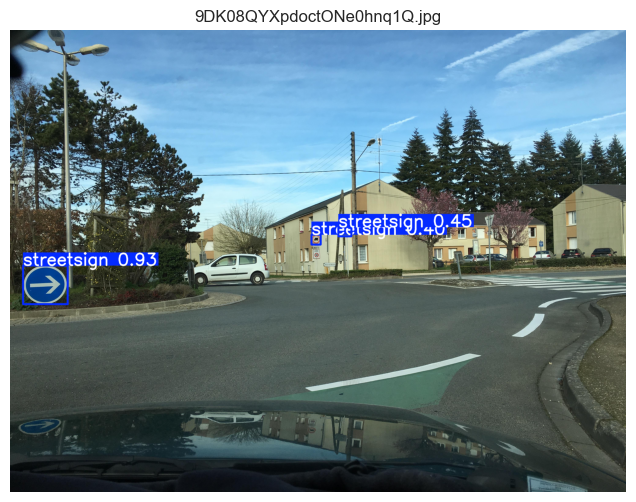

In [23]:
import matplotlib.pyplot as plt
from PIL import Image
import glob
import random
import os

# Path to validation image folder (NOT a single image)
IMAGE_DIR = r"E:\DataMiningProj\Git_project\street_signs\dataset\images\val"

# Collect all images
image_paths = (
    glob.glob(os.path.join(IMAGE_DIR, "*.jpg")) +
    glob.glob(os.path.join(IMAGE_DIR, "*.png"))
)

# Pick one random image
img_path = random.choice(image_paths)

# Print filename
print("Selected image:", os.path.basename(img_path))

# Run YOLO on the single image
results = yolo_model(img_path, conf=0.3)

# Plot result
annotated = results[0].plot()
annotated = annotated[:, :, ::-1]  # BGR → RGB

plt.figure(figsize=(10, 6))
plt.imshow(annotated)
plt.title(os.path.basename(img_path))
plt.axis("off")
plt.show()

plt.close()
